# Advanced HCI Lab — Sound Classification with CNN (Major vs Minor)
This notebook loads WAV files from the KaggleHub cache (or any folder you point it to),
extracts **Chroma CQT features**, trains a small CNN, then evaluates with **accuracy, F1-score, and confusion matrix**.

**Classes:** `Major` vs `Minor` (2 classes)

## 0) Setup
Run the next cell to import everything we need (optimized: all imports in one place).

In [1]:
# ==== Optimized Imports (run once) ====
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, accuracy_score


## 1) Point to your dataset folder
Set `BASE_DIR` to the folder that contains `Major/` and `Minor/` WAV files.

Example (your path):
`...\Audio_Files`

In [2]:

# ==== Dataset Path ====
BASE_DIR = r"C:\Users\Lenovo\.cache\kagglehub\datasets\deepcontractor\musical-instrument-chord-classification\versions\2\Audio_Files"

major_files = glob.glob(os.path.join(BASE_DIR, "Major", "*.wav"))
minor_files = glob.glob(os.path.join(BASE_DIR, "Minor", "*.wav"))

print("Major files:", len(major_files))
print("Minor files:", len(minor_files))

assert len(major_files) > 0 and len(minor_files) > 0, (
    "No WAV files found. Check BASE_DIR. It should contain folders: Major/ and Minor/"
)

# Optional: shuffle for randomness/reproducibility
random.seed(42)
random.shuffle(major_files)
random.shuffle(minor_files)


Major files: 502
Minor files: 357


## 2) Feature extraction: Chroma CQT (fixed size)
CNN requires all inputs to have the same shape, so we **pad/trim** time frames to `MAX_FRAMES`.

Output shape per audio file: `(N_CHROMA, MAX_FRAMES)`.


In [3]:
# ==== Chroma CQT settings ====
SR = 22050
HOP_LENGTH = 512
N_CHROMA = 12
MAX_FRAMES = 174  # controls width (time axis). If you change this, rebuild the model.

def extract_chroma_cqt(path, sr=SR, hop_length=HOP_LENGTH, n_chroma=N_CHROMA, max_frames=MAX_FRAMES):
    """Load audio file and return normalized Chroma-CQT (n_chroma, max_frames)."""
    y, sr = librosa.load(path, sr=sr)

    chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length, n_chroma=n_chroma)  # (n_chroma, time)

    # pad/trim to max_frames
    if chroma.shape[1] < max_frames:
        chroma = np.pad(chroma, ((0, 0), (0, max_frames - chroma.shape[1])), mode="constant")
    else:
        chroma = chroma[:, :max_frames]

    # normalize
    chroma = (chroma - chroma.mean()) / (chroma.std() + 1e-9)

    return chroma.astype(np.float32)

# Quick test on one file
test_path = major_files[0]
chroma_feat = extract_chroma_cqt(test_path)
print("Test file:", test_path)
print("Chroma-CQT shape:", chroma_feat.shape)


C:\Users\Lenovo\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\Lenovo\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\Lenovo\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Test file: C:\Users\Lenovo\.cache\kagglehub\datasets\deepcontractor\musical-instrument-chord-classification\versions\2\Audio_Files\Major\Major_151.wav
Chroma-CQT shape: (12, 174)


C:\Users\Lenovo\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=758
  warnings.warn(


### (Optional) Visualize one spectrogram
This is useful for teaching: treat the spectrogram like an image.

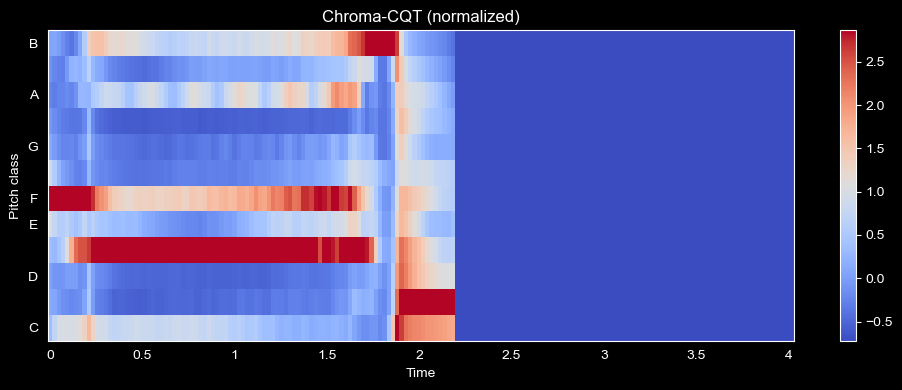

In [4]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(chroma_feat, x_axis="time", y_axis="chroma", sr=SR, hop_length=HOP_LENGTH)
plt.colorbar()
plt.title("Chroma-CQT (normalized)")
plt.tight_layout()
plt.show()


## 3) Build dataset arrays (X, y)
We build:
- `X`: spectrograms shaped `(N, 128, 174, 1)`
- `y`: one-hot labels shaped `(N, 2)`

Tip: start with a smaller subset to test quickly, then increase.

In [5]:
# ==== Choose how many samples to load per class ====
N_PER_CLASS = 300  # change to None to use all available

maj = major_files if N_PER_CLASS is None else major_files[:min(N_PER_CLASS, len(major_files))]
minr = minor_files if N_PER_CLASS is None else minor_files[:min(N_PER_CLASS, len(minor_files))]

files = maj + minr
labels = [0] * len(maj) + [1] * len(minr)  # 0=Major, 1=Minor

print("Using files:", len(files), "(Major:", len(maj), "Minor:", len(minr), ")")

# Extract features (can take a bit depending on N_PER_CLASS)
X = np.array([extract_chroma_cqt(f) for f in files], dtype=np.float32)
X = X[..., np.newaxis]  # add channel dim -> (N, 12, 174, 1)

y = tf.keras.utils.to_categorical(labels, num_classes=2)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Train/test split (stratified keeps class balance)
X_train, X_test, y_train, y_test, labels_train, labels_test = train_test_split(
    X, y, labels, test_size=0.2, random_state=42, stratify=labels
)


Using files: 600 (Major: 300 Minor: 300 )


C:\Users\Lenovo\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=776
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=793
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=741
  warnings.warn(


X shape: (600, 12, 174, 1)
y shape: (600, 2)


## 4) Build the CNN model
We use **GlobalAveragePooling2D** to avoid shape issues if you change pooling/frames.
Output is 2-class softmax: Major vs Minor.

In [11]:
tf.keras.backend.clear_session()
sound_model = models.Sequential([
    layers.Input(shape=(N_CHROMA, MAX_FRAMES, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPool2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPool2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPool2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(2, activation="softmax")
])
sound_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
sound_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 12, 174, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 87, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 87, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 43, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 43, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 21, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,586 (107.76 KB)

 Trainable params: 27,586 (107.76 KB)

 Non-trainable params: 0 (0.00 B)

## 5) Train
This trains on `X_train/y_train` with validation split.
If you see memory issues, reduce `BATCH_SIZE`.

In [12]:
EPOCHS = 30
BATCH_SIZE = 32

history = sound_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)


Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5208 - loss: 0.6928 - val_accuracy: 0.4583 - val_loss: 0.6974
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5547 - loss: 0.6840 - val_accuracy: 0.5208 - val_loss: 0.6878
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5417 - loss: 0.6788 - val_accuracy: 0.6354 - val_loss: 0.6722
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6094 - loss: 0.6676 - val_accuracy: 0.5521 - val_loss: 0.6781
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6172 - loss: 0.6574 - val_accuracy: 0.5312 - val_loss: 0.6803
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6510 - loss: 0.6364 - val_accuracy: 0.6458 - val_loss: 0.6329
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6927 - loss: 0.6025 - val_accuracy: 0.6250 - val_loss: 0.6235
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7188 - loss: 0.5805 - val_accuracy: 0.6562 - val_

### Training curves (accuracy & loss)

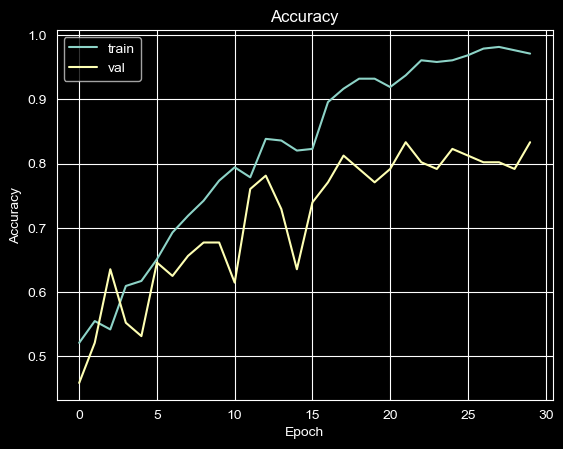

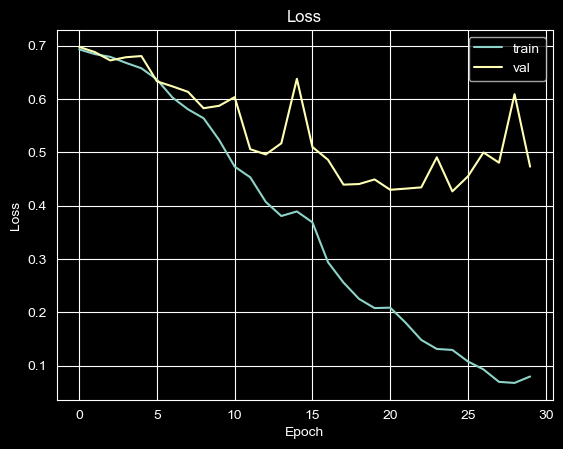

In [13]:
# Accuracy
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])
plt.show()

# Loss
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()


## 6) Evaluation (required validation scores)
We compute:
- Test Accuracy
- Macro F1-score
- Confusion Matrix
- Full Classification Report (precision/recall/F1 per class)

Test Accuracy: 0.775
Macro F1-score: 0.7737272155876807


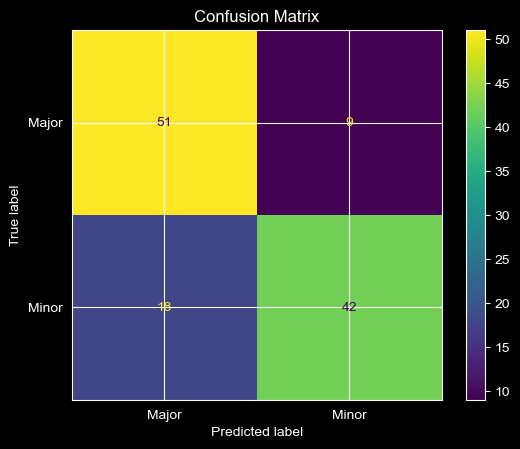


Classification Report:
              precision    recall  f1-score   support

       Major       0.74      0.85      0.79        60
       Minor       0.82      0.70      0.76        60

    accuracy                           0.78       120
   macro avg       0.78      0.77      0.77       120
weighted avg       0.78      0.78      0.77       120



In [14]:
# Predict on test set
y_prob = sound_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)          # predicted labels: 0/1
y_true = np.argmax(y_test, axis=1)          # true labels: 0/1

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print("Test Accuracy:", acc)
print("Macro F1-score:", f1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Major", "Minor"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Major", "Minor"]))


## 7) Quick single-file test (inference)
Pick any WAV and see the predicted class.

In [10]:
sample_path = minor_files[0]  # change to any file you want
sample_feat = extract_chroma_cqt(sample_path)[np.newaxis, ..., np.newaxis]  # (1, 12, 174, 1)

probs = sound_model.predict(sample_feat, verbose=0)[0]
pred_idx = int(np.argmax(probs))
pred_label = "Major" if pred_idx == 0 else "Minor"

print("File:", sample_path)
print("Probabilities [Major, Minor]:", probs)
print("Prediction:", pred_label)


File: C:\Users\Lenovo\.cache\kagglehub\datasets\deepcontractor\musical-instrument-chord-classification\versions\2\Audio_Files\Minor\Minor_110.wav
Probabilities [Major, Minor]: [0.08933157 0.9106685 ]
Prediction: Minor


C:\Users\Lenovo\anaconda3\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=758
  warnings.warn(
